In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

import pingouin as pg
import os
from tqdm import tqdm
import plotly.graph_objects as go

from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import ElasticNet

warnings.filterwarnings('ignore')
# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False


In [2]:
df = pd.read_excel(r'E:\pycharm all files\眼动数据处理\飞行得分预测\data_clean.xlsx')
# Control
df = df[df['组别'] == 1]
df

,组别,受试者,session,SCL_mean,AOI_Transition,SGE,GTE,HR,SDNN,RMSSD,...,Cz_α/β_low,Cz_θ/β_low,Fz_α/β_low,Fz_θ/β_low,Pz_α/β_low,Pz_θ/β_low,DE_Cz_β_low,DE_Fz_β_low,DE_Pz_β_low,label
112,1,冯晓娅,1,0.007088,8.357143,0.482332,0.261099,-30.536503,-74.022441,-78.582040,...,-0.481898,-0.331498,-0.481389,-0.109862,-0.273509,0.414012,0.279550,0.263806,0.235134,0
113,1,冯晓娅,2,0.006915,9.357143,0.537987,0.265556,-14.674020,-96.630447,-102.599160,...,-0.090817,-0.003043,-2.267632,-1.692027,3.669581,3.160712,-0.131972,0.191698,-0.111783,2
114,1,冯晓娅,3,0.006741,10.357143,0.593642,0.270014,-6.002873,3.596953,6.265917,...,-0.124811,0.154970,-1.757231,-2.024374,-1.169127,-1.931064,0.076338,0.020234,0.164095,2
115,1,冯晓娅,4,0.006568,11.357143,0.649297,0.274471,-12.358863,31.211233,41.535566,...,-1.826960,-2.642410,0.132878,0.119234,0.314573,0.290045,0.284481,0.246408,0.336284,2
116,1,冯晓娅,5,0.006394,12.357143,0.704952,0.278928,-4.703051,8.694954,1.419180,...,0.099581,-0.067367,1.215161,1.464706,0.740944,1.077448,0.605060,0.605060,0.605060,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219,1,陈妍,3,-0.070973,21.535714,1.521286,0.548103,-2.053871,38.025352,38.134196,...,-2.250823,-1.649062,59.993978,54.627684,8.394237,8.630346,0.381392,0.223729,-0.002783,3
220,1,陈妍,4,-0.088214,18.071429,1.326411,0.441623,-6.284982,-16.635726,-24.647037,...,2.933417,2.996113,21.678034,17.809093,1.321222,-0.889454,0.143382,-0.145777,0.145758,2
221,1,陈妍,5,-0.105455,14.607143,1.131536,0.335144,-1.159217,17.134339,17.823007,...,-2.169963,-1.248641,-0.534875,0.934625,-0.242793,1.074378,0.605060,0.605060,0.605060,0
222,1,陈妍,6,-0.122697,11.142857,0.936661,0.228664,-5.534589,-22.075732,-34.098901,...,6.521421,6.660803,-1.820669,-1.495729,1.656347,-1.115062,0.166768,0.268078,0.045828,1


In [3]:
X_cols = [
    'SCL_mean', 'AOI_Transition', 'SGE', 'GTE',
    'HR', 'SDNN', 'RMSSD',
    'Cz_β_high', 'Fz_β_high', 'Pz_β_high',
    'Cz_α/β_high', 'Cz_θ/β_high',
    'Fz_α/β_high', 'Fz_θ/β_high',
    'Pz_α/β_high', 'Pz_θ/β_high',
    'DE_Cz_β_high', 'DE_Fz_β_high', 'DE_Pz_β_high',
    'Cz_β_low', 'Fz_β_low', 'Pz_β_low',
    'Cz_α/β_low', 'Cz_θ/β_low',
    'Fz_α/β_low', 'Fz_θ/β_low',
    'Pz_α/β_low', 'Pz_θ/β_low',
    'DE_Cz_β_low', 'DE_Fz_β_low', 'DE_Pz_β_low'
]

# 可选：把组别和 session 也加进去
X_cols += ['session']

X = df[X_cols]
y = df['label']
groups = df['受试者']


In [4]:
X

,SCL_mean,AOI_Transition,SGE,GTE,HR,SDNN,RMSSD,Cz_β_high,Fz_β_high,Pz_β_high,...,Cz_α/β_low,Cz_θ/β_low,Fz_α/β_low,Fz_θ/β_low,Pz_α/β_low,Pz_θ/β_low,DE_Cz_β_low,DE_Fz_β_low,DE_Pz_β_low,session
112,0.007088,8.357143,0.482332,0.261099,-30.536503,-74.022441,-78.582040,0.019290,0.016932,0.046688,...,-0.481898,-0.331498,-0.481389,-0.109862,-0.273509,0.414012,0.279550,0.263806,0.235134,1
113,0.006915,9.357143,0.537987,0.265556,-14.674020,-96.630447,-102.599160,8.450198,0.142722,0.345645,...,-0.090817,-0.003043,-2.267632,-1.692027,3.669581,3.160712,-0.131972,0.191698,-0.111783,2
114,0.006741,10.357143,0.593642,0.270014,-6.002873,3.596953,6.265917,0.200181,0.202082,0.169465,...,-0.124811,0.154970,-1.757231,-2.024374,-1.169127,-1.931064,0.076338,0.020234,0.164095,3
115,0.006568,11.357143,0.649297,0.274471,-12.358863,31.211233,41.535566,0.680291,0.148969,0.032145,...,-1.826960,-2.642410,0.132878,0.119234,0.314573,0.290045,0.284481,0.246408,0.336284,4
116,0.006394,12.357143,0.704952,0.278928,-4.703051,8.694954,1.419180,0.044127,0.245735,0.010898,...,0.099581,-0.067367,1.215161,1.464706,0.740944,1.077448,0.605060,0.605060,0.605060,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219,-0.070973,21.535714,1.521286,0.548103,-2.053871,38.025352,38.134196,0.480506,0.781104,0.844972,...,-2.250823,-1.649062,59.993978,54.627684,8.394237,8.630346,0.381392,0.223729,-0.002783,3
220,-0.088214,18.071429,1.326411,0.441623,-6.284982,-16.635726,-24.647037,0.858444,0.287205,0.201724,...,2.933417,2.996113,21.678034,17.809093,1.321222,-0.889454,0.143382,-0.145777,0.145758,4
221,-0.105455,14.607143,1.131536,0.335144,-1.159217,17.134339,17.823007,0.638032,0.071052,0.083395,...,-2.169963,-1.248641,-0.534875,0.934625,-0.242793,1.074378,0.605060,0.605060,0.605060,5
222,-0.122697,11.142857,0.936661,0.228664,-5.534589,-22.075732,-34.098901,0.810403,0.183523,0.279126,...,6.521421,6.660803,-1.820669,-1.495729,1.656347,-1.115062,0.166768,0.268078,0.045828,6


In [5]:
from sklearn.model_selection import GroupKFold

gkf = GroupKFold(n_splits=8)  # 32人 → 8折，每折4人


# 采用ElasticNet模型

In [6]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', ElasticNet(max_iter=10000))
])

param_grid = {
    'model__alpha': np.logspace(-3, 1, 20),
    'model__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}

gkf = GroupKFold(n_splits=8)

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=gkf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid.fit(X, y, groups=groups)

baseline_rmse = mean_squared_error(
    y,
    np.full_like(y, y.mean()),
    squared=False
)

print("最优参数:", grid.best_params_)
print("CV RMSE:", -grid.best_score_)
print("Baseline RMSE:", baseline_rmse)

最优参数: {'model__alpha': 0.20691380811147903, 'model__l1_ratio': 0.9}
CV RMSE: 0.9924094647560067
Baseline RMSE: 1.1687905837109693


# 被试级预测性能评估（不是 session 级）

In [7]:
from sklearn.model_selection import cross_val_predict

y_pred = cross_val_predict(
    grid.best_estimator_,
    X, y,
    cv=gkf,
    groups=groups
)

rmse = mean_squared_error(y, y_pred, squared=False)
r2 = r2_score(y, y_pred)

print("被试级 RMSE:", rmse)
print("R²:", r2)


被试级 RMSE: 1.0233027120152485
R²: 0.020840101632469965


In [8]:
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np


def group_cv_rmse_r2(estimator, X, y, groups, n_splits=8):
    gkf = GroupKFold(n_splits=n_splits)

    y_true_all = []
    y_pred_all = []

    for train_idx, test_idx in gkf.split(X, y, groups):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        estimator.fit(X_train, y_train)
        y_pred = estimator.predict(X_test)

        y_true_all.append(y_test.values)
        y_pred_all.append(y_pred)

    y_true_all = np.concatenate(y_true_all)
    y_pred_all = np.concatenate(y_pred_all)

    rmse = mean_squared_error(y_true_all, y_pred_all, squared=False)
    r2 = r2_score(y_true_all, y_pred_all)

    return rmse, r2


In [9]:
from sklearn.linear_model import Ridge

ridge_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge())
])

ridge_param = {
    'model__alpha': np.logspace(-3, 3, 20)
}

ridge_grid = GridSearchCV(
    ridge_pipe,
    ridge_param,
    cv=gkf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

ridge_grid.fit(X, y, groups=groups)


GridSearchCV(cv=GroupKFold(n_splits=8),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model', Ridge())]),
             n_jobs=-1,
             param_grid={'model__alpha': array([1.00000000e-03, 2.06913808e-03, 4.28133240e-03, 8.85866790e-03,
       1.83298071e-02, 3.79269019e-02, 7.84759970e-02, 1.62377674e-01,
       3.35981829e-01, 6.95192796e-01, 1.43844989e+00, 2.97635144e+00,
       6.15848211e+00, 1.27427499e+01, 2.63665090e+01, 5.45559478e+01,
       1.12883789e+02, 2.33572147e+02, 4.83293024e+02, 1.00000000e+03])},
             scoring='neg_root_mean_squared_error')

In [10]:
from sklearn.linear_model import Lasso

lasso_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso(max_iter=10000))
])

lasso_param = {
    'model__alpha': np.logspace(-4, 1, 20)
}

lasso_grid = GridSearchCV(
    lasso_pipe,
    lasso_param,
    cv=gkf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

lasso_grid.fit(X, y, groups=groups)


GridSearchCV(cv=GroupKFold(n_splits=8),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model', Lasso(max_iter=10000))]),
             n_jobs=-1,
             param_grid={'model__alpha': array([1.00000000e-04, 1.83298071e-04, 3.35981829e-04, 6.15848211e-04,
       1.12883789e-03, 2.06913808e-03, 3.79269019e-03, 6.95192796e-03,
       1.27427499e-02, 2.33572147e-02, 4.28133240e-02, 7.84759970e-02,
       1.43844989e-01, 2.63665090e-01, 4.83293024e-01, 8.85866790e-01,
       1.62377674e+00, 2.97635144e+00, 5.45559478e+00, 1.00000000e+01])},
             scoring='neg_root_mean_squared_error')

In [11]:
from sklearn.svm import SVR

svr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVR(kernel='rbf'))
])

svr_param = {
    'model__C': np.logspace(-2, 2, 5),
    'model__gamma': np.logspace(-3, 0, 5)
}

svr_grid = GridSearchCV(
    svr_pipe,
    svr_param,
    cv=gkf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

svr_grid.fit(X, y, groups=groups)


GridSearchCV(cv=GroupKFold(n_splits=8),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model', SVR())]),
             n_jobs=-1,
             param_grid={'model__C': array([1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02]),
                         'model__gamma': array([0.001     , 0.00562341, 0.03162278, 0.17782794, 1.        ])},
             scoring='neg_root_mean_squared_error')

In [12]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_param = {
    'model__max_depth': [3, 5, 10, None],
    'model__min_samples_leaf': [1, 3, 5]
}

rf_pipe = Pipeline([
    ('model', rf)
])

rf_grid = GridSearchCV(
    rf_pipe,
    rf_param,
    cv=gkf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

rf_grid.fit(X, y, groups=groups)


GridSearchCV(cv=GroupKFold(n_splits=8),
             estimator=Pipeline(steps=[('model',
                                        RandomForestRegressor(n_estimators=300,
                                                              n_jobs=-1,
                                                              random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [3, 5, 10, None],
                         'model__min_samples_leaf': [1, 3, 5]},
             scoring='neg_root_mean_squared_error')

In [13]:
enet_rmse, enet_r2 = group_cv_rmse_r2(
    grid.best_estimator_, X, y, groups
)
ridge_rmse, ridge_r2 = group_cv_rmse_r2(
    ridge_grid.best_estimator_, X, y, groups
)
lasso_rmse, lasso_r2 = group_cv_rmse_r2(
    lasso_grid.best_estimator_, X, y, groups
)
svr_rmse, svr_r2 = group_cv_rmse_r2(
    svr_grid.best_estimator_, X, y, groups
)
rf_rmse, rf_r2 = group_cv_rmse_r2(
    rf_grid.best_estimator_, X, y, groups
)

In [14]:
y_pred_base = np.full_like(y, y.mean())
baseline_rmse = mean_squared_error(y, y_pred_base, squared=False)
baseline_r2 = r2_score(y, y_pred_base)

print(f"{'Baseline':10s}  RMSE = {baseline_rmse},r2 = {baseline_r2}")  # r2 ≈ 0

Baseline    RMSE = 1.1687905837109693,r2 = -0.27737607156168465


In [15]:
results = {
    'ElasticNet': (enet_rmse, enet_r2),
    'Ridge': (ridge_rmse, ridge_r2),
    'Lasso': (lasso_rmse, lasso_r2),
    'SVR (RBF)': (svr_rmse, svr_r2),
    'Random Forest': (rf_rmse, rf_r2),
    'Baseline': (baseline_rmse, baseline_r2)
}

for model, (rmse, r2) in results.items():
    print(f"{model:15s}  RMSE = {rmse:.3f} | R² = {r2:.3f}")


ElasticNet       RMSE = 1.023 | R² = 0.021
Ridge            RMSE = 1.326 | R² = -0.644
Lasso            RMSE = 1.024 | R² = 0.019
SVR (RBF)        RMSE = 1.056 | R² = -0.042
Random Forest    RMSE = 1.031 | R² = 0.006
Baseline         RMSE = 1.169 | R² = -0.277


# 可选增强（如果你想再榨一点性能）

## 方案 A：PCA + Ridge（最稳、最推荐）

In [16]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_predict

pipe_pca_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA()),
    ('model', Ridge())
])

param_grid = {
    'pca__n_components': [0.8, 0.9, 0.95],
    'model__alpha': np.logspace(-3, 3, 20)
}

gkf = GroupKFold(n_splits=8)

grid_pca_ridge = GridSearchCV(
    pipe_pca_ridge,
    param_grid,
    cv=gkf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid_pca_ridge.fit(X, y, groups=groups)

print("最优参数:", grid_pca_ridge.best_params_)
print("CV RMSE:", -grid_pca_ridge.best_score_)

y_pred = cross_val_predict(
    grid_pca_ridge.best_estimator_,
    X, y,
    cv=gkf,
    groups=groups
)

print("被试级 RMSE:", mean_squared_error(y, y_pred, squared=False))
print("R²:", r2_score(y, y_pred))


最优参数: {'model__alpha': 1000.0, 'pca__n_components': 0.9}
CV RMSE: 1.0384669583769177
被试级 RMSE: 1.0691558457961066
R²: -0.06887617803162516


## 方案 B：按模态分组 PCA（更高级、更“论文感”）

In [17]:
eye_features = ['AOI_Transition', 'SGE', 'GTE']
hrv_features = ['HR', 'SDNN', 'RMSSD']
scl_features = ['SCL_mean']

eeg_high = [c for c in X.columns if 'high' in c]
eeg_low = [c for c in X.columns if 'low' in c]
other_features = ['session']


In [18]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('eye', StandardScaler(), eye_features),
        ('hrv', StandardScaler(), hrv_features),
        ('scl', StandardScaler(), scl_features),
        ('eeg_high', Pipeline([
            ('scaler', StandardScaler()),
            ('pca', PCA(n_components=0.9))
        ]), eeg_high),
        ('eeg_low', Pipeline([
            ('scaler', StandardScaler()),
            ('pca', PCA(n_components=0.9))
        ]), eeg_low),
        ('other', StandardScaler(), other_features)
    ]
)


In [19]:
pipe_grouped = Pipeline([
    ('preprocess', preprocessor),
    ('model', Ridge(alpha=1.0))
])

param_grid = {
    'model__alpha': np.logspace(-3, 3, 20)
}

grid_grouped = GridSearchCV(
    pipe_grouped,
    param_grid,
    cv=gkf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid_grouped.fit(X, y, groups=groups)

print("最优参数:", grid_grouped.best_params_)
print("CV RMSE:", -grid_grouped.best_score_)

y_pred = cross_val_predict(
    grid_grouped.best_estimator_,
    X, y,
    cv=gkf,
    groups=groups
)

print("被试级 RMSE:", mean_squared_error(y, y_pred, squared=False))
print("R²:", r2_score(y, y_pred))


最优参数: {'model__alpha': 1000.0}
CV RMSE: 1.2260136814511404
被试级 RMSE: 1.3213793187518832
R²: -0.6326773914045469


# permutation

In [20]:
"""
对每一次 permutation：

对每个被试：
随机打乱该被试 7 个 session 的 label
用 完全相同的 ElasticNet + GroupKFold
计算被试级 R²
重复 1000 次
计算
"""
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet

best_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', ElasticNet(
        alpha=0.12742749857031335,
        l1_ratio=0.9,
        max_iter=10000
    ))
])


In [21]:
gkf = GroupKFold(n_splits=8)


def subject_level_r2(X, y, groups, model):
    y_pred = cross_val_predict(
        model,
        X, y,
        cv=gkf,
        groups=groups
    )
    return r2_score(y, y_pred)


In [22]:
real_r2 = subject_level_r2(X, y, groups, best_model)
print("Real R²:", real_r2)


Real R²: -29.37365469647765


In [23]:
import numpy as np
from tqdm import trange

n_perm = 1000
perm_r2 = np.zeros(n_perm)

y_array = y.values.copy()
groups_array = groups.values

rng = np.random.default_rng(42)

for i in trange(n_perm):
    y_perm = y_array.copy()

    for subj in np.unique(groups_array):
        idx = np.where(groups_array == subj)[0]
        y_perm[idx] = rng.permutation(y_perm[idx])

    perm_r2[i] = subject_level_r2(X, y_perm, groups, best_model)


100%|██████████| 1000/1000 [00:28<00:00, 35.01it/s]


In [24]:
p_value = (np.sum(perm_r2 >= real_r2) + 1) / (n_perm + 1)
print("Permutation p-value:", p_value)

Permutation p-value: 0.6263736263736264


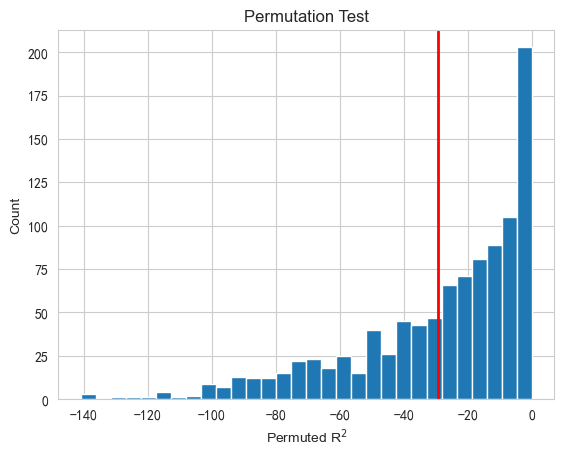

In [35]:
# 绘图核心代码（已添加局部Arial字体设置）
plt.hist(perm_r2, bins=30)
plt.axvline(real_r2, color='red', linewidth=2)  # 红色垂直线
plt.xlabel("Permuted R$^2$", fontfamily='Arial')  # X轴标签设为Arial
plt.ylabel("Count", fontfamily='Arial')  # Y轴标签设为Arial
plt.title("Permutation Test", fontfamily='Arial')  # 标题设为Arial

# 保存图片（文件名已对应Control组）
plt.savefig("Control_permutation_test.png", dpi=300, bbox_inches='tight')
plt.show()

In [26]:
model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', ElasticNet(
        alpha=0.12742749857031335,
        l1_ratio=0.9,
        max_iter=10000
    ))
])

In [27]:
gkf = GroupKFold(n_splits=8)

coef_matrix = []

for train_idx, test_idx in gkf.split(X, y, groups):
    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]

    model.fit(X_train, y_train)

    coef = model.named_steps['model'].coef_
    coef_matrix.append(coef)

coef_matrix = np.array(coef_matrix)  # shape: (n_folds, n_features)

In [28]:
feature_names = X.columns

stability_df = pd.DataFrame({
    'feature': feature_names,
    'selection_freq': np.mean(coef_matrix != 0, axis=0),
    'mean_coef': np.mean(coef_matrix, axis=0),
    'std_coef': np.std(coef_matrix, axis=0),
    'sign_consistency': np.mean(np.sign(coef_matrix) == np.sign(np.mean(coef_matrix)), axis=0)
})

stability_df = stability_df.sort_values('selection_freq', ascending=False)

In [29]:
print(stability_df)

           feature  selection_freq  mean_coef  std_coef  sign_consistency
31         session           1.000   0.291329  0.056970             1.000
3              GTE           0.875  -0.048094  0.035365             0.000
27      Pz_θ/β_low           0.750   0.034671  0.036846             0.750
15     Pz_θ/β_high           0.625   0.017517  0.018796             0.625
25      Fz_θ/β_low           0.500   0.020011  0.021240             0.500
24      Fz_α/β_low           0.375   0.021018  0.045586             0.375
11     Cz_θ/β_high           0.125   0.009950  0.026325             0.125
20        Fz_β_low           0.125  -0.000960  0.002541             0.000
14     Pz_α/β_high           0.125   0.001907  0.005045             0.125
0         SCL_mean           0.125   0.012328  0.032617             0.125
2              SGE           0.125  -0.011614  0.030729             0.000
10     Cz_α/β_high           0.000   0.000000  0.000000             0.000
9        Pz_β_high           0.000   0

# 预测图

In [30]:
from sklearn.model_selection import cross_val_predict

df_subj = cross_val_predict(
    best_model,
    X, y,
    cv=gkf,
    groups=groups
)
n = 16  # 重复次数
session = [i for _ in range(n) for i in range(1, 8)]
# print(session)

df_subj = pd.DataFrame({
    'subject': groups.values,
    'y_true': y.values,
    'y_pred': y_pred,
    'Session': session
})
df_subj

,subject,y_true,y_pred,Session
0,冯晓娅,0,1.585033,1
1,冯晓娅,2,1.607584,2
2,冯晓娅,2,1.588563,3
3,冯晓娅,2,1.631233,4
4,冯晓娅,1,1.660931,5
...,...,...,...,...
107,陈妍,3,1.693095,3
108,陈妍,2,1.598104,4
109,陈妍,0,1.639590,5
110,陈妍,1,1.653264,6


In [31]:
df_subj_mean = df_subj.drop(columns='Session')
df_subj_mean = df_subj_mean.groupby(["subject"]).mean()
df_subj_mean

,y_true,y_pred
subject,,
冯晓娅,1.285714,1.625029
冯科嘉,0.714286,1.606953
刘勇杰,1.428571,1.561806
周鑫颜,1.285714,3.407813
朱娇娇,1.285714,1.707040
杜佳鑫,2.285714,1.345844
毛华灏,2.000000,1.435052
王子铭,1.285714,1.668249
祖丽米热,1.285714,1.501871


In [32]:
y_true = df_subj_mean['y_true']
y_pred = df_subj_mean['y_pred']
y_pred

subject
冯晓娅     1.625029
冯科嘉     1.606953
刘勇杰     1.561806
周鑫颜     3.407813
朱娇娇     1.707040
杜佳鑫     1.345844
毛华灏     1.435052
王子铭     1.668249
祖丽米热    1.501871
祝鹏程     1.604539
程腾宇     1.560491
肖雨晨     1.497832
胡浩男     1.563166
董嘉乐     1.411627
郭浚杰     1.458271
陈妍      1.607015
Name: y_pred, dtype: float64

In [33]:
y_true

subject
冯晓娅     1.285714
冯科嘉     0.714286
刘勇杰     1.428571
周鑫颜     1.285714
朱娇娇     1.285714
杜佳鑫     2.285714
毛华灏     2.000000
王子铭     1.285714
祖丽米热    1.285714
祝鹏程     1.285714
程腾宇     1.285714
肖雨晨     2.142857
胡浩男     1.142857
董嘉乐     2.428571
郭浚杰     2.571429
陈妍      1.000000
Name: y_true, dtype: float64

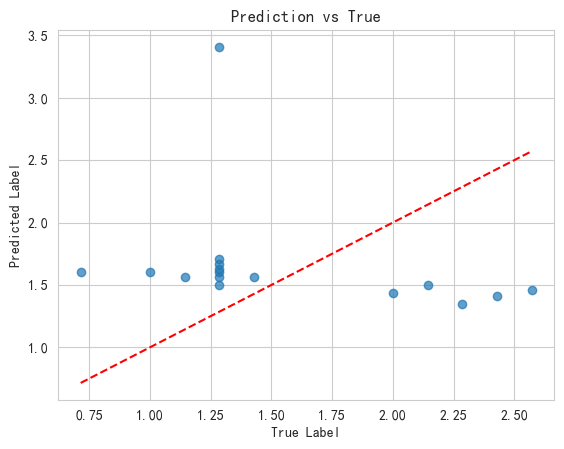

In [34]:
plt.scatter(y_true, y_pred, alpha=0.7)
plt.plot([y_true.min(), y_true.max()],
         [y_true.min(), y_true.max()],
         'r--')

plt.xlabel("True Label")
plt.ylabel("Predicted Label")
plt.title("Prediction vs True")
plt.show()